In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
cpu = np.fromfile("/cosmos_storage/data_sharing/tmp_resims/1080-A/haloes_2/output/cpu.csv", sep=', ')

/tmp/ipykernel_255326/955572315.py:1: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  cpu = np.fromfile("/cosmos_storage/data_sharing/tmp_resims/1080-A/haloes_2/output/cpu.csv", sep=', ')


In [77]:
def read_cpu(filename=None, skiprows=[]):
    with open(filename) as f:
        lines = f.readlines()

    d = {}

    i=0
    for line in lines:
        line.strip()

        if i == 0:
            columns = [item.strip() for item in line.split(',')]
            for index, elem in enumerate(columns[:-1]):
                d[columns[index]] = []
        elif i in skiprows:
            i = i + 1
            continue
        else:
            data = [item.strip() for item in line.split(',')]
            for index, elem in enumerate(data[:-1]):
                d[columns[index]].append(float(data[index]))
        i = i + 1

    return d

In [78]:
file = "/cosmos_storage/data_sharing/tmp_resims/1080-A/haloes_2/output/cpu.csv"
cpu_2 = read_cpu(filename=file)

file = "/cosmos_storage/data_sharing/tmp_resims/1080-A/haloes_4/output/cpu.csv"
cpu_4 = read_cpu(filename=file)

file = "/cosmos_storage/data_sharing/tmp_resims/1080-A/haloes_10/output/cpu.csv"
cpu_10 = read_cpu(filename=file, skiprows=[373])

Text(0.5, 0, '$N_{halos}$')

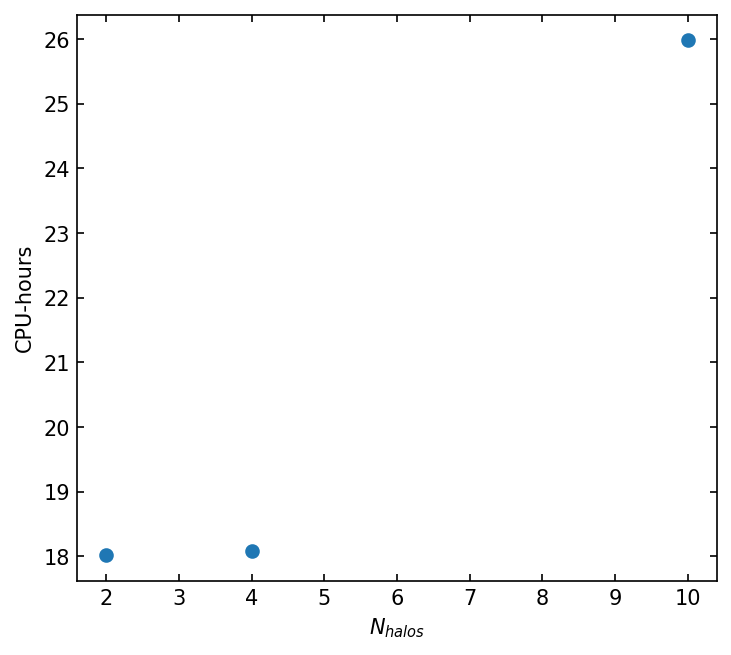

In [100]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.plot(2, cpu_2['CPU_ALL1'][-1]/3600*16, marker='o', color='C0')
ax.plot(4, cpu_4['CPU_ALL1'][-1]/3600*16, marker='o', color='C0')
ax.plot(10, cpu_10['CPU_ALL1'][-1]/3600*16, marker='o', color='C0')

ax.set_ylabel('CPU-hours')
ax.set_xlabel('$N_{halos}$')

In [91]:
cpu_2.keys()

dict_keys(['STEP', 'TIME', 'CPUS', 'MULTIPLEDOMAIN', 'HIGHESTTIMEBIN', 'CPU_ALL1', 'CPU_ALL2', 'CPU_ALL3', 'CPU_TREE1', 'CPU_TREE2', 'CPU_TREE3', 'CPU_TREEBUILD1', 'CPU_TREEBUILD2', 'CPU_TREEBUILD3', 'CPU_TREEBUILD_INSERT1', 'CPU_TREEBUILD_INSERT2', 'CPU_TREEBUILD_INSERT3', 'CPU_TREEBUILD_BRANCHES1', 'CPU_TREEBUILD_BRANCHES2', 'CPU_TREEBUILD_BRANCHES3', 'CPU_TREEBUILD_TOPLEVEL1', 'CPU_TREEBUILD_TOPLEVEL2', 'CPU_TREEBUILD_TOPLEVEL3', 'CPU_TREEFORCE1', 'CPU_TREEFORCE2', 'CPU_TREEFORCE3', 'CPU_TREEWALK1', 'CPU_TREEWALK2', 'CPU_TREEWALK3', 'CPU_TREEIMBALANCE1', 'CPU_TREEIMBALANCE2', 'CPU_TREEIMBALANCE3', 'CPU_TREEFETCH1', 'CPU_TREEFETCH2', 'CPU_TREEFETCH3', 'CPU_TREESTACK1', 'CPU_TREESTACK2', 'CPU_TREESTACK3', 'CPU_PM_GRAVITY1', 'CPU_PM_GRAVITY2', 'CPU_PM_GRAVITY3', 'CPU_NGBTREEBUILD1', 'CPU_NGBTREEBUILD2', 'CPU_NGBTREEBUILD3', 'CPU_NGBTREEUPDATEVEL1', 'CPU_NGBTREEUPDATEVEL2', 'CPU_NGBTREEUPDATEVEL3', 'CPU_NGBTREEUPDATEMAXHSML1', 'CPU_NGBTREEUPDATEMAXHSML2', 'CPU_NGBTREEUPDATEMAXHSML3', 'C

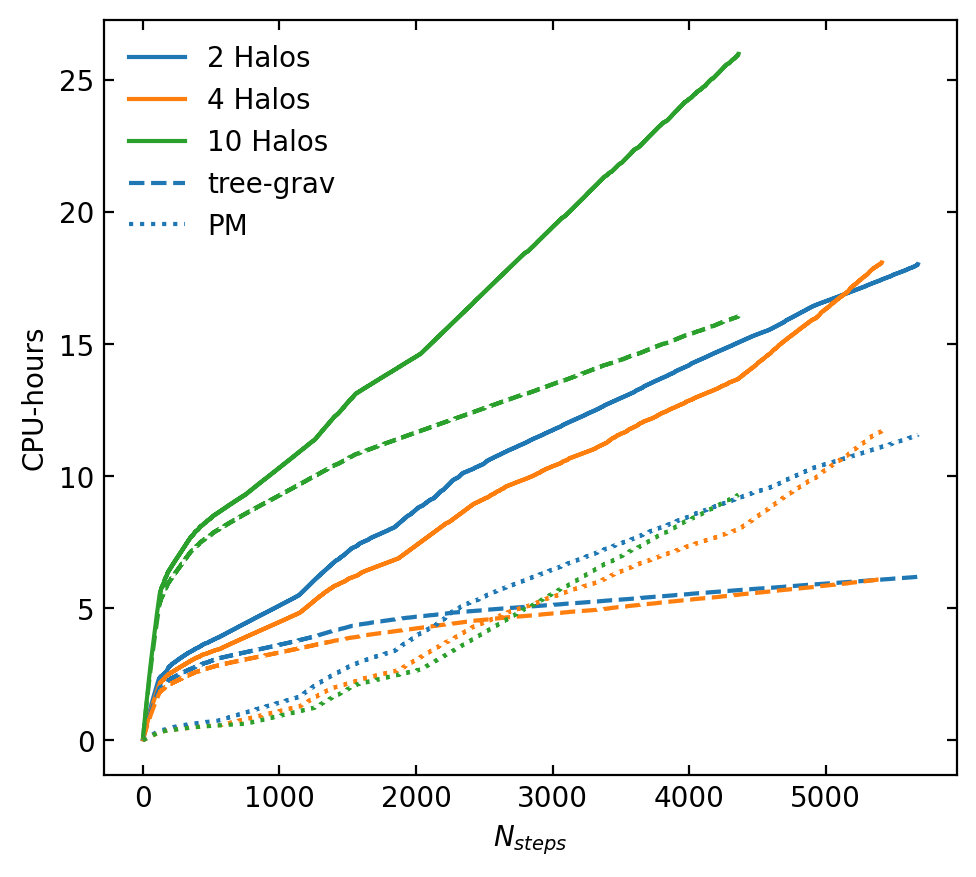

In [95]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5, 5))

ax.plot(cpu_2['STEP'], np.array(cpu_2['CPU_ALL1'])/3600*16, label='2 Halos', color='C0')
ax.plot(cpu_4['STEP'], np.array(cpu_4['CPU_ALL1'])/3600*16, label='4 Halos', color='C1')
ax.plot(cpu_10['STEP'], np.array(cpu_10['CPU_ALL1'])/3600*16, label='10 Halos', color='C2')

ax.plot(cpu_2['STEP'], np.array(cpu_2['CPU_TREE1'])/3600*16, color='C0', ls='--', label='tree-grav')
ax.plot(cpu_4['STEP'], np.array(cpu_4['CPU_TREE1'])/3600*16, color='C1', ls='--')
ax.plot(cpu_10['STEP'], np.array(cpu_10['CPU_TREE1'])/3600*16, color='C2', ls='--')

ax.plot(cpu_2['STEP'], np.array(cpu_2['CPU_PM_GRAVITY1'])/3600*16, color='C0', ls=':', label='PM')
ax.plot(cpu_4['STEP'], np.array(cpu_4['CPU_PM_GRAVITY1'])/3600*16, color='C1', ls=':')
ax.plot(cpu_10['STEP'], np.array(cpu_10['CPU_PM_GRAVITY1'])/3600*16, color='C2', ls=':')

ax.set_xlabel('$N_{steps}$')
ax.set_ylabel('CPU-hours')

ax.legend()